# Telco Customer Churn - İstatistiksel Analiz
Kaynak veri seti: [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# TotalCharges bazı satırlarda boşluk karakteri içeriyor (yeni müşteriler), sayısala çeviriyoruz
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# churn'ü ikili sayısal değişkene çeviriyoruz (0/1)
df["churn"] = df["Churn"].map({"No": 0, "Yes": 1})

sayisal_sutunlar = ["tenure", "MonthlyCharges", "TotalCharges"]
kategorik_sutunlar = ["Contract", "PaymentMethod", "Churn"]

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()


Veri seti: 7043 satır, 22 sütun


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


##  Genel Bakış Özet

In [ ]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer": df.isnull().sum(),
    "eksik_değer_yüzdesi": (df.isnull().mean()*100).round(2)
})

ozet


,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
customerID,str,7043,0,0.00
gender,str,2,0,0.00
SeniorCitizen,int64,2,0,0.00
Partner,str,2,0,0.00
Dependents,str,2,0,0.00
tenure,int64,73,0,0.00
PhoneService,str,2,0,0.00
MultipleLines,str,3,0,0.00
InternetService,str,3,0,0.00
OnlineSecurity,str,3,0,0.00


In [ ]:
print("tekrar eden satır:", df.duplicated().sum())
print(df["Contract"].value_counts())


tekrar eden satır: 0
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


## **Betimsel İstatistik ve güven aralığı**

In [ ]:
def ortalama_guven_aralığı(seri, guven=0.95):
  veri = seri.dropna()
  n = len(veri)
  ortalama = veri.mean()
  sem = stats.sem(veri) # standart error of the mean
  t_kritik = stats.t.ppf((1+guven)/2, df=n-1)
  hata_payi = t_kritik*sem
  return ortalama, ortalama-hata_payi, ortalama+hata_payi

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
  ortalama, alt, ust = ortalama_guven_aralığı(df[degisken])
  print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")


değişken            ,    Ortalama,     %95 Alt,     %95 Üst
tenure              ,       32.37,       31.80,       32.94
MonthlyCharges      ,       64.76,       64.06,       65.46
TotalCharges        ,     2283.30,     2230.31,     2336.29


In [ ]:
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
betimsel.round(2)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,0.24,-1.39
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,-0.22,-1.26
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80,0.96,-0.23


## **Normallik Testleri**

In [ ]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>16s} Yorum ")
for col in sayisal_sutunlar:
  veri = df[col].dropna()
  # shapiro n> 5000 den fazla olursa güvenilmez olur
  ornek = veri.sample(min(len(veri), 5000), random_state=0)
  sw_stat, sw_p = stats.shapiro(ornek)
  da_stat, da_p = stats.normaltest(veri)
  yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
  print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")


Değişken               Shapiro-Wilk p      DAgostino p Yorum 
tenure                         0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
MonthlyCharges                 0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
TotalCharges                   0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.


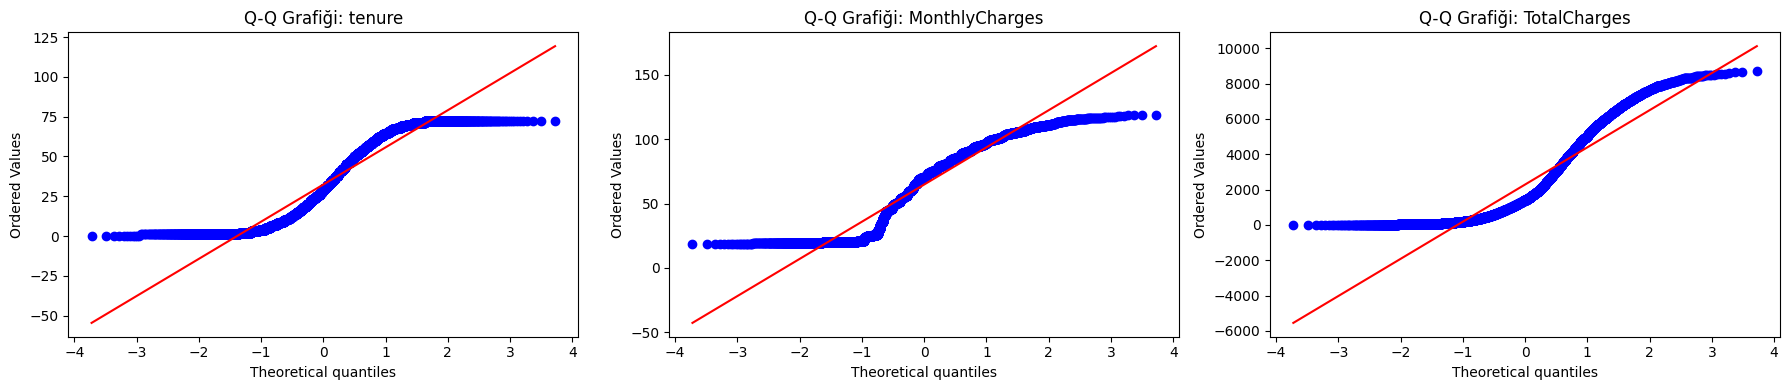

In [ ]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()


## **İki Grup Karşılaştırması**

In [ ]:
grup0 = df.loc[df["churn"] == 0, "MonthlyCharges"].dropna()
grup1 = df.loc[df["churn"] == 1, "MonthlyCharges"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")
__, p0 = stats.shapiro(grup0.sample(min(len(grup0), 5000), random_state=0))
__, p1 = stats.shapiro(grup1.sample(min(len(grup1), 5000), random_state=0))
normal_mi = (p0 > 0.05) and (p1 > 0.05)
print(f"grup normallik p değerleri: churn=0 -> {p0:.4f}, churn=1 -> {p1:.4f}")


Varsayımlar homojen değildir.
grup normallik p değerleri: churn=0 -> 0.0000, churn=1 -> 0.0000


In [ ]:
# Normallik sağlanmadığı için (Shapiro p<0.05) Mann-Whitney U testi kullanıyoruz
u_stat, mw_p = stats.mannwhitneyu(grup0, grup1)
t_stat, t_p = stats.ttest_ind(grup0, grup1, equal_var=(levene_p > 0.05))

print(f"Mann-Whitney U: u={u_stat:.1f}, p={mw_p:.6f}")
print(f"Bağımsız örneklem t-testi: t={t_stat:.3f}, p={t_p:.6f}")
print(f"churn=0 ortalama MonthlyCharges: {grup0.mean():.2f}")
print(f"churn=1 ortalama MonthlyCharges: {grup1.mean():.2f}")


Mann-Whitney U: u=3667080.5, p=0.000000
Bağımsız örneklem t-testi: t=-18.408, p=0.000000
churn=0 ortalama MonthlyCharges: 61.27
churn=1 ortalama MonthlyCharges: 74.44


# **çoklu grup karşılaştırması**

In [ ]:
gruplar = [g["MonthlyCharges"].dropna().values for _, g in df.groupby("Contract")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

print(f" tek yönlü anova: f={f_stat:.3f}, p={anova_p:.4f}")
print(f"kruskal-wallis: h={h_stat:.3f}, p={kw_p:.4f}")


 tek yönlü anova: f=20.828, p=0.0000
kruskal-wallis: h=21.226, p=0.0000


In [ ]:
genel_ortalama = df["MonthlyCharges"].mean()
ss_between = sum(len(g)*(g.mean()-genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["MonthlyCharges"].dropna()-genel_ortalama)**2)
eta_kare = ss_between/ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")


Eta Kare: 0.0059 (0.01 küçük, 0.06 orta, 0.14 büyük etki)


In [ ]:
#post-hoc
tukey = pairwise_tukeyhsd(
    endog=df["MonthlyCharges"].dropna(),
    groups=df.loc[df["MonthlyCharges"].notna(), "Contract"],
    alpha=0.05
)

print(tukey)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1      group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
Month-to-month One year  -1.3499 0.3056 -3.5029  0.8032  False
Month-to-month Two year  -5.6281    0.0 -7.6764 -3.5797   True
      One year Two year  -4.2782 0.0002 -6.7838 -1.7726   True
--------------------------------------------------------------


## Kategorik Değişkenler Arasındaki İlişki

In [ ]:
def cramers_v(x, y):
  tablo = pd.crosstab(x, y)
  chi2 = stats.chi2_contingency(tablo)[0]
  n = tablo.sum().sum()
  k = min(tablo.shape)-1
  return np.sqrt(chi2/(n*k))

capraz = pd.crosstab(df["Contract"], df["Churn"])
chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
v = cramers_v(df["Contract"], df["Churn"])
print(f"chi2={chi2:.4f}, p={p:.4f}, v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print(capraz)


chi2=1184.5966, p=0.0000, v=0.4101


Cramer's V: 0.4101

 Çapraz Tablo
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


## **Korelasyon Analizi**

In [ ]:
def korelasyon_p_matrisi(veri, yontem="pearson"):
  sutunlar = veri.columns
  kat = pd.DataFrame(np.ones((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
  pval = pd.DataFrame(np.zeros((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
  for i in sutunlar:
    for j in sutunlar:
      if i == j:
        kat.loc[i, j] = 1.0
        pval.loc[i, j] = 0.0
        continue
      ortak = veri[[i, j]].dropna()
      x_seri, y_seri = ortak.iloc[:, 0], ortak.iloc[:, 1]
      if yontem == "pearson":
        r, p = stats.pearsonr(x_seri, y_seri)
      else:
        r, p = stats.spearmanr(x_seri, y_seri)
      kat.loc[i, j] = float(r)
      pval.loc[i, j] = float(p)
  return kat, pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar], "pearson")
print("--- pearson korelasyon katsayıları ---")
print(pearson_r)
print("\n--- pearson p değerleri ---")
print(pearson_p.round(4))


--- pearson korelasyon katsayıları ---
                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000

--- pearson p değerleri ---
                tenure  MonthlyCharges  TotalCharges
tenure             0.0             0.0           0.0
MonthlyCharges     0.0             0.0           0.0
TotalCharges       0.0             0.0           0.0


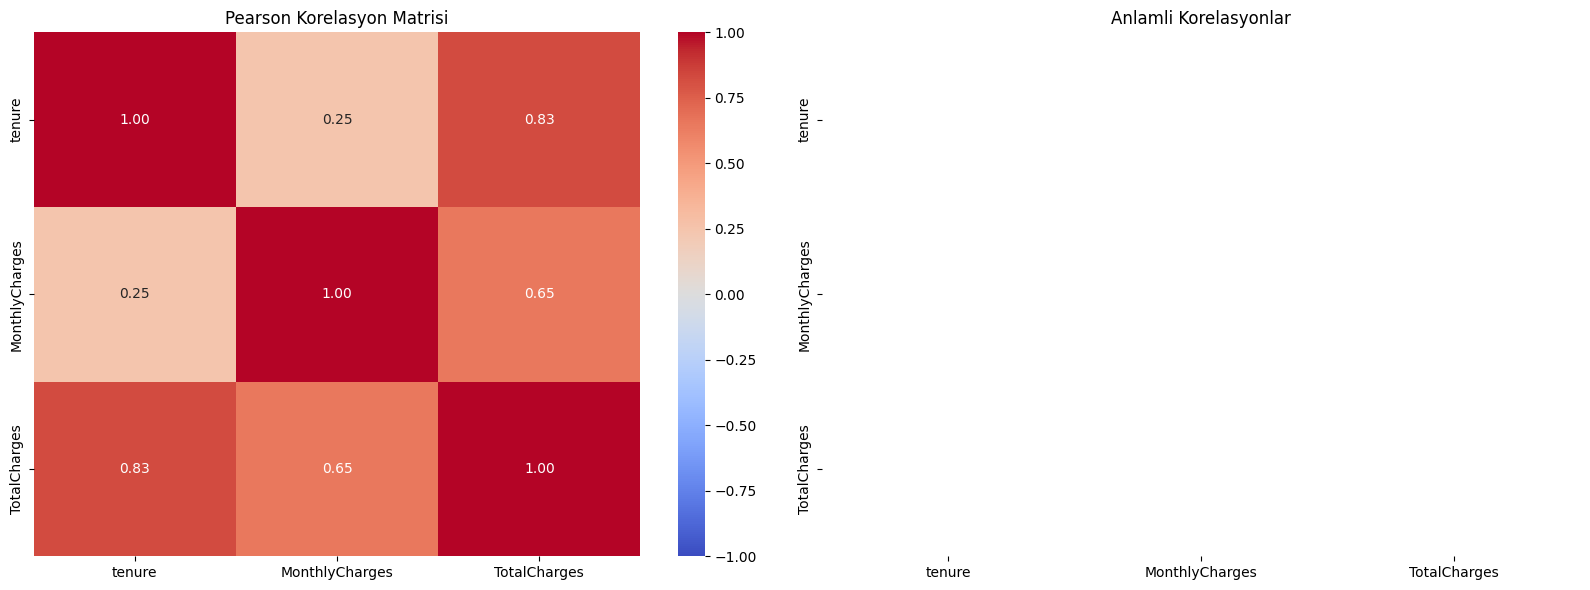

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05

sns.heatmap(pearson_p, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, mask=~anlamli_maske, ax=axes[1], cbar=False)
axes[1].set_title("Anlamli Korelasyonlar")
plt.tight_layout()
plt.show()


## **Çoklu Doğrusal Bağlantı(Multicollinerity)**

* VIF < 5 sorun yok rahatız
* 5 <VIF<10 dikkat
* VIF>10 yandı gülüm keten helva o değişkenlerle o iş olmaz

In [ ]:
X_vif = df[["tenure", "MonthlyCharges"]].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i] for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu)


         Değişken       VIF
0          tenure  1.065478
1  MonthlyCharges  1.065478


# **Keşifci Regresyon**

In [ ]:
model_verisi = df[["TotalCharges", "tenure", "MonthlyCharges"]].dropna()
model = smf.ols(formula="TotalCharges~tenure+MonthlyCharges", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())


                            OLS Regression Results                            
Dep. Variable:           TotalCharges   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.997e+04
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:11:26   Log-Likelihood:                -56382.
No. Observations:                7032   AIC:                         1.128e+05
Df Residuals:                    7029   BIC:                         1.128e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -2162.4319     21.990    -98.

## Temel Bileşenler Analizi(PCA)

In [ ]:
pca_verisi = df[sayisal_sutunlar].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
acıklanan_varyans = pca.explained_variance_ratio_
print(acıklanan_varyans)


[0.72659927 0.25358707 0.01981367]
